#                                 Working on MNIST Dataset Without Principal Component Analysis (PCA)

## -> importing libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## -> Loading Dataset 

In [2]:
df = pd.read_csv('mnist_data.csv')

## ->Preprocessing

#### As in my case data is already preprocessed , I only need to separate  Features and Labels

In [3]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
(60000, 785)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 

### ->To see how the image looks

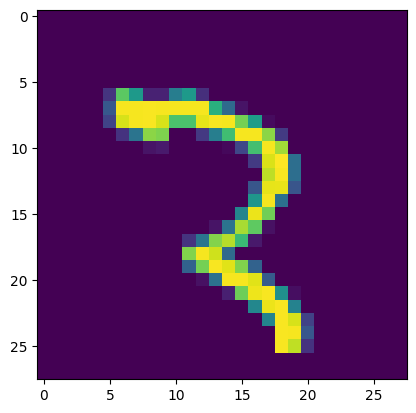

In [4]:
plt.imshow(df.iloc[500, 1:].values.reshape(28, 28))
plt.show()


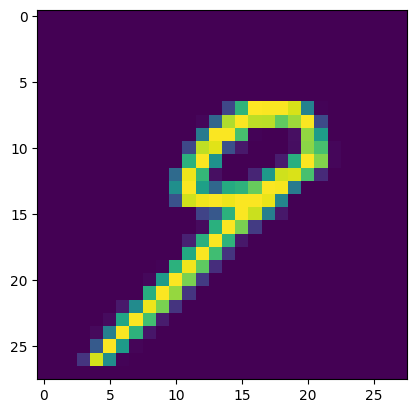

In [5]:
plt.imshow(df.iloc[501, 1:].values.reshape(28, 28))
plt.show()

## ->Separating Features and Labels

In [6]:
X = df.drop("label",axis= 1)
Y= df["label"]

## ->Train 80%,Test 20 % 

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [8]:
X_train.shape

(48000, 784)

In [9]:
X_test.shape

(12000, 784)

## ->ML Model , KNN Classifier (without using PCA)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

In [11]:
KNN = KNeighborsClassifier()
KNN.fit(X_train,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## ->I also calculate the time 

In [12]:
import time 
start = time.time()
y_pred = KNN.predict(X_test)
print(time.time()-start)

30.82435393333435


## I got 97.15 % accuracy score

In [13]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_test,y_pred))

0.9715


#                                 Working on MNIST Dataset With Principal Component Analysis (PCA)

## ->Before applying PCA ,it is better to standardize the values

In [21]:
X_trf = df.drop("label", axis=1)
Y_trf = df["label"]

In [22]:
X_train_trf, X_test_trf, Y_train_trf, Y_test_trf = train_test_split(
    X_trf,
    Y_trf,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_trf)
X_test_scaled = scaler.transform(X_test_trf)

## Now Applying PCA

In [29]:
from sklearn.decomposition import PCA 
pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original shape:", X_train_trf.shape)
print("PCA shape:", X_train_pca.shape)

Original shape: (48000, 784)
PCA shape: (48000, 100)


## ->ML Model , KNN Classifier (with using PCA)

In [30]:
from sklearn.neighbors import KNeighborsClassifier

## After Applying PCA , my accuracy score is still 96% but I have reduced the dimensionality from 784 to 3 dimensions

In [31]:


KNN_PCA = KNeighborsClassifier()

KNN_PCA.fit(X_train_pca, Y_train_trf)

Y_pred_pca = KNN_PCA.predict(X_test_pca)

from sklearn.metrics import accuracy_score

print("PCA KNN Accuracy:", accuracy_score(Y_test_trf, Y_pred_pca))

PCA KNN Accuracy: 0.96025


# Visualization

In [32]:
%pip install plotly

  Using cached plotly-7.0.0-py3-none-any.whl.metadata (8.7 kB)
Using cached plotly-7.0.0-py3-none-any.whl (9.1 MB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


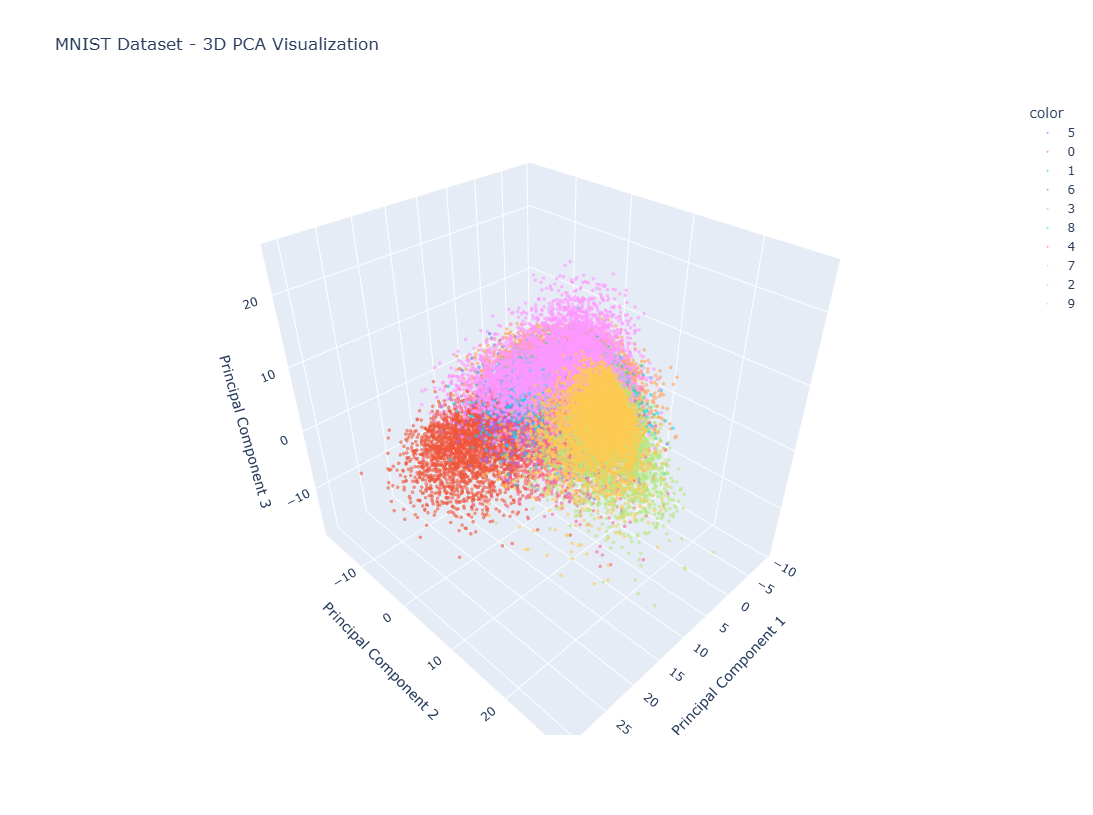

In [34]:
import plotly.express as px

# Convert labels to strings so Plotly treats them as categories
labels = Y_train_trf.astype(str)

fig = px.scatter_3d(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    z=X_train_pca[:, 2],
    color=labels,
    labels={
        "x": "Principal Component 1",
        "y": "Principal Component 2",
        "z": "Principal Component 3"
    },
    title="MNIST Dataset - 3D PCA Visualization"
)

fig.update_traces(
    marker=dict(
        size=2,
        opacity=0.6
    )
)
fig.update_layout(
    width=1200,
    height=800
)

fig.show()

